# 04 — Spending profiles

This notebook creates a simple candidate-level spending dataset from the cleaned
2024 ORESTAR transactions.

For now we focus on:

- total reported expenditure amount;
- number of reported expenditure transactions;
- average and median expenditure;
- spending composition by expenditure-size bin.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

YEAR = 2024

cwd = Path.cwd()

if (cwd / "pyproject.toml").exists():
    ROOT = cwd
elif (cwd.parent / "pyproject.toml").exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find repository root.")

TRANSACTIONS_PATH = (
    ROOT / "data" / "clean" / "orestar" / str(YEAR)
    / "transactions.csv"
)

AUDIT_PATH = (
    ROOT / "data" / "clean" / "orestar" / str(YEAR)
    / "file_audit.csv"
)

CROSSWALK_PATH = (
    ROOT / "data" / "processed" / "master"
    / f"candidate_source_crosswalk_{YEAR}.csv"
)

OUTPUT_DIR = (
    ROOT / "data" / "processed" / "spending" / str(YEAR)
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("Transactions exist:", TRANSACTIONS_PATH.exists())
print("Crosswalk exists:", CROSSWALK_PATH.exists())

ROOT: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis
Transactions exist: True
Crosswalk exists: True


## 1. Load ORESTAR and inspect the spending definition

In [2]:
transactions = pd.read_csv(
    TRANSACTIONS_PATH,
    low_memory=False,
)

print("ORESTAR rows:", f"{len(transactions):,}")
print("Columns:", len(transactions.columns))

print("\nSub types:")
display(transactions["sub_type"].value_counts(dropna=False))

print("\nReported expenditure flag:")
display(
    transactions["is_reported_expenditure"]
    .value_counts(dropna=False)
)

ORESTAR rows: 35,542
Columns: 53

Sub types:


sub_type
Cash Contribution                         20410
Cash Expenditure                          12384
Personal Expenditure for Reimbursement     1081
In-Kind Contribution                        403
Account Payable                             366
Return or Refund of Contribution            308
Refunds and Rebates                         178
Items Sold at Fair Market Value              93
Lost or Returned Check                       88
Miscellaneous Other Receipt                  66
Loan Received (Non-Exempt)                   58
Interest/Investment Income                   31
Miscellaneous Other Disbursement             24
Loan Payment (Non-Exempt)                    17
Cash Balance Adjustment                      10
In-Kind/Forgiven Personal Expenditures        9
Loan Forgiven (Non-Exempt)                    6
Account Payable Rescinded                     4
Loan Received (Exempt)                        2
In-Kind/Forgiven Account Payable              2
Miscellaneous Account Receivabl


Reported expenditure flag:


is_reported_expenditure
False    22053
True     13489
Name: count, dtype: int64

In [3]:
spending = transactions.loc[
    transactions["is_reported_expenditure"]
    .fillna(False)
    .astype(bool)
].copy()

spending["reported_expenditure_amount"] = pd.to_numeric(
    spending["reported_expenditure_amount"],
    errors="coerce",
)

spending = spending.loc[
    spending["reported_expenditure_amount"].notna()
    & spending["reported_expenditure_amount"].gt(0)
].copy()

print("Reported expenditure rows:", f"{len(spending):,}")
print(
    "Reported expenditure amount:",
    f"${spending['reported_expenditure_amount'].sum():,.2f}",
)

Reported expenditure rows: 13,489
Reported expenditure amount: $7,853,887.19


## 2. Keep the known ORESTAR duplicate-export issue visible

We do not modify the raw files here. The audit is displayed so the known
`Penson.xls` / `Morse.xls` issue remains explicit.

In [4]:
audit = pd.read_csv(AUDIT_PATH, low_memory=False)

duplicate_exports = audit.loc[
    audit["is_exact_duplicate_export"]
    .fillna(False)
    .astype(bool)
].copy()

print("Exact duplicate export rows:", len(duplicate_exports))

display(
    duplicate_exports[
        [
            "district",
            "source_file",
            "source_file_hash",
            "same_hash_file_count",
        ]
    ]
    if len(duplicate_exports)
    else duplicate_exports
)

Exact duplicate export rows: 4


,district,source_file,source_file_hash,same_hash_file_count
28,2,Penson.xls,122c395765679c92a70fe95a4abd4e3847067a305539f0...,2
49,3,Morse.xls,f4d27e719c151b49391886c0b2e1ce9f17e5a8e9b3888e...,2
52,3,Penson.xls,122c395765679c92a70fe95a4abd4e3847067a305539f0...,2
67,4,Morse.xls,f4d27e719c151b49391886c0b2e1ce9f17e5a8e9b3888e...,2


## 3. Attach ORESTAR records to official candidates

Only confirmed crosswalk matches are used. Wrong-district/unmatched finance
records are not silently assigned to an official candidate.

In [5]:
crosswalk = pd.read_csv(CROSSWALK_PATH, low_memory=False)

orestar_crosswalk = crosswalk.loc[
    crosswalk["source"].eq("orestar")
].copy()

matched_orestar = (
    orestar_crosswalk.loc[
        orestar_crosswalk["classification"].eq("match"),
        [
            "year",
            "district",
            "source_candidate_name",
            "suggested_candidate",
            "suggested_candidate_key",
        ],
    ]
    .rename(
        columns={
            "suggested_candidate": "canonical_candidate",
            "suggested_candidate_key": "candidate_key",
        }
    )
    .drop_duplicates()
)

spending = spending.merge(
    matched_orestar,
    left_on=["year", "district", "source_file_stem"],
    right_on=["year", "district", "source_candidate_name"],
    how="left",
    validate="many_to_one",
)

print(
    "Expenditure rows linked to official candidates:",
    f"{spending['canonical_candidate'].notna().sum():,}",
)
print(
    "Expenditure rows not linked:",
    f"{spending['canonical_candidate'].isna().sum():,}",
)

Expenditure rows linked to official candidates: 12,517
Expenditure rows not linked: 972


In [6]:
unmatched_spending = (
    spending.loc[
        spending["canonical_candidate"].isna()
    ]
    .groupby(
        ["district", "source_file_stem", "filer"],
        as_index=False,
        dropna=False,
    )
    .agg(
        expenditure_rows=("reported_expenditure_amount", "size"),
        total_expenditure=("reported_expenditure_amount", "sum"),
    )
    .sort_values(
        ["district", "total_expenditure"],
        ascending=[True, False],
    )
)

display(unmatched_spending)

spending = spending.loc[
    spending["canonical_candidate"].notna()
].copy()

print(
    "Official candidates with reported spending:",
    spending["canonical_candidate"].nunique(),
)

,district,source_file_stem,filer,expenditure_rows,total_expenditure
0,1,Durphy,Friends of Jamie Dunphy,391,111237.32
1,1,McKenzie,Friends of Sonja McKenzie,39,5426.76
4,2,Middleton,Middleton for District 2,58,6643.41
2,2,Burnell,Friends of David Burnell,31,5049.82
5,2,Sherman,Friends of Brooklyn,54,4240.16
3,2,Emerson,Joseph Emerson for Portland City Council,23,1584.91
7,3,Penson,Friends of Tiffani,178,143910.77
6,3,Morse,Friends of Tony Morse,172,81288.87
9,4,Underdahl,Soren for Portland,23,1886.77
8,4,Kaluba,Chomba for Portland,3,325.00


Official candidates with reported spending: 66


## 4. Candidate spending totals

In [7]:
spending_summary = (
    spending
    .groupby(
        ["year", "district", "candidate_key", "canonical_candidate"],
        as_index=False,
    )
    .agg(
        total_spending=("reported_expenditure_amount", "sum"),
        expenditure_count=("reported_expenditure_amount", "size"),
        average_expenditure=("reported_expenditure_amount", "mean"),
        median_expenditure=("reported_expenditure_amount", "median"),
    )
    .sort_values(
        ["district", "total_spending"],
        ascending=[True, False],
    )
)

display(spending_summary.head(30))

,year,district,candidate_key,canonical_candidate,total_spending,expenditure_count,average_expenditure,median_expenditure
5,2024,1,2024|1|loretta smith,Loretta Smith,1464141.21,1510,969.629940,100.895
7,2024,1,2024|1|steph routh,Steph Routh,201809.37,572,352.813584,8.720
0,2024,1,2024|1|candace avalos,Candace Avalos,177221.93,470,377.067936,78.260
10,2024,1,2024|1|timur ender,Timur Ender,157642.42,160,985.265125,184.870
8,2024,1,2024|1|terrence hayes,Terrence Hayes,92626.13,197,470.183401,68.780
6,2024,1,2024|1|noah ernst,Noah Ernst,60028.06,136,441.382794,195.000
1,2024,1,2024|1|cayle tern,Cayle Tern,13202.71,72,183.370972,80.000
3,2024,1,2024|1|deian salazar,Deian Salazar,5326.85,76,70.090132,20.825
2,2024,1,2024|1|david linn,David Linn,5176.49,66,78.431667,15.990
9,2024,1,2024|1|thomas shervey,Thomas Shervey,2223.98,25,88.959200,14.990


## 5. Simple spending profile by expenditure size

Initial bins:

- Micro: ≤ $25
- Small: > $25 and ≤ $100
- Medium: > $100 and ≤ $250
- Large: > $250 and ≤ $1,000
- Mega: > $1,000

These are a simple first representation, not a claim that these are the optimal
substantive spending categories. Purpose-code profiles can come later.

In [8]:
BIN_LABELS = ["Micro", "Small", "Medium", "Large", "Mega"]

spending["expenditure_bin"] = pd.cut(
    spending["reported_expenditure_amount"],
    bins=[-np.inf, 25, 100, 250, 1000, np.inf],
    labels=BIN_LABELS,
    right=True,
    ordered=True,
)

display(
    spending["expenditure_bin"]
    .value_counts(sort=False)
)

expenditure_bin
Micro     4277
Small     3137
Medium    1651
Large     2113
Mega      1339
Name: count, dtype: int64

In [9]:
spending_profile_long = (
    spending
    .groupby(
        [
            "year",
            "district",
            "candidate_key",
            "canonical_candidate",
            "expenditure_bin",
        ],
        observed=False,
        as_index=False,
    )
    .agg(
        spending_amount=("reported_expenditure_amount", "sum"),
        spending_count=("reported_expenditure_amount", "size"),
    )
)

profile_totals = (
    spending_profile_long
    .groupby(
        ["year", "district", "candidate_key", "canonical_candidate"],
        as_index=False,
    )
    .agg(
        profile_total_spending=("spending_amount", "sum"),
        profile_total_count=("spending_count", "sum"),
    )
)

spending_profile_long = spending_profile_long.merge(
    profile_totals,
    on=["year", "district", "candidate_key", "canonical_candidate"],
    how="left",
    validate="many_to_one",
)

spending_profile_long["spending_amount_share"] = (
    spending_profile_long["spending_amount"]
    / spending_profile_long["profile_total_spending"]
)

spending_profile_long["spending_count_share"] = (
    spending_profile_long["spending_count"]
    / spending_profile_long["profile_total_count"]
)

display(spending_profile_long.head(10))

,year,district,candidate_key,canonical_candidate,expenditure_bin,spending_amount,spending_count,profile_total_spending,profile_total_count,spending_amount_share,spending_count_share
0,2024,1,2024|1|candace avalos,Candace Avalos,Micro,1353.50,150,177221.93,470,0.007637,0.319149
1,2024,1,2024|1|candace avalos,Candace Avalos,Small,7027.16,116,177221.93,470,0.039652,0.246809
2,2024,1,2024|1|candace avalos,Candace Avalos,Medium,12667.39,76,177221.93,470,0.071478,0.161702
3,2024,1,2024|1|candace avalos,Candace Avalos,Large,51604.78,90,177221.93,470,0.291187,0.191489
4,2024,1,2024|1|candace avalos,Candace Avalos,Mega,104569.10,38,177221.93,470,0.590046,0.080851
5,2024,1,2024|1|cayle tern,Cayle Tern,Micro,195.10,25,13202.71,72,0.014777,0.347222
6,2024,1,2024|1|cayle tern,Cayle Tern,Small,1104.67,17,13202.71,72,0.083670,0.236111
7,2024,1,2024|1|cayle tern,Cayle Tern,Medium,1627.98,11,13202.71,72,0.123307,0.152778
8,2024,1,2024|1|cayle tern,Cayle Tern,Large,10274.96,19,13202.71,72,0.778246,0.263889
9,2024,1,2024|1|cayle tern,Cayle Tern,Mega,0.00,0,13202.71,72,0.000000,0.000000


## 6. Validate profile shares

In [10]:
validation = (
    spending_profile_long
    .groupby(
        ["year", "district", "candidate_key", "canonical_candidate"],
        as_index=False,
    )
    .agg(
        amount_share_sum=("spending_amount_share", "sum"),
        count_share_sum=("spending_count_share", "sum"),
    )
)

validation["amount_share_ok"] = np.isclose(
    validation["amount_share_sum"], 1.0
)
validation["count_share_ok"] = np.isclose(
    validation["count_share_sum"], 1.0
)

print(
    "All amount-share profiles valid:",
    validation["amount_share_ok"].all(),
)
print(
    "All count-share profiles valid:",
    validation["count_share_ok"].all(),
)

display(validation.head())

All amount-share profiles valid: True
All count-share profiles valid: True


,year,district,candidate_key,canonical_candidate,amount_share_sum,count_share_sum,amount_share_ok,count_share_ok
0,2024,1,2024|1|candace avalos,Candace Avalos,1.0,1.0,True,True
1,2024,1,2024|1|cayle tern,Cayle Tern,1.0,1.0,True,True
2,2024,1,2024|1|david linn,David Linn,1.0,1.0,True,True
3,2024,1,2024|1|deian salazar,Deian Salazar,1.0,1.0,True,True
4,2024,1,2024|1|joe furi,Joe Furi,1.0,1.0,True,True


## 7. Wide spending profile

In [11]:
metrics = [
    "spending_amount",
    "spending_amount_share",
    "spending_count",
    "spending_count_share",
]

wide_parts = []

for metric in metrics:
    part = (
        spending_profile_long
        .pivot(
            index=[
                "year",
                "district",
                "candidate_key",
                "canonical_candidate",
            ],
            columns="expenditure_bin",
            values=metric,
        )
        .reindex(columns=BIN_LABELS)
        .fillna(0)
    )

    part.columns = [
        f"{metric}_{str(bin_name).lower()}"
        for bin_name in part.columns
    ]

    wide_parts.append(part)

spending_profile_wide = pd.concat(
    wide_parts,
    axis=1,
).reset_index()

spending_profile_wide = spending_profile_wide.merge(
    spending_summary,
    on=["year", "district", "candidate_key", "canonical_candidate"],
    how="left",
    validate="one_to_one",
)

display(spending_profile_wide.head())

,year,district,candidate_key,canonical_candidate,spending_amount_micro,spending_amount_small,spending_amount_medium,spending_amount_large,spending_amount_mega,spending_amount_share_micro,spending_amount_share_small,spending_amount_share_medium,spending_amount_share_large,spending_amount_share_mega,spending_count_micro,spending_count_small,spending_count_medium,spending_count_large,spending_count_mega,spending_count_share_micro,spending_count_share_small,spending_count_share_medium,spending_count_share_large,spending_count_share_mega,total_spending,expenditure_count,average_expenditure,median_expenditure
0,2024,1,2024|1|candace avalos,Candace Avalos,1353.50,7027.16,12667.39,51604.78,104569.10,0.007637,0.039652,0.071478,0.291187,0.590046,150,116,76,90,38,0.319149,0.246809,0.161702,0.191489,0.080851,177221.93,470,377.067936,78.260
1,2024,1,2024|1|cayle tern,Cayle Tern,195.10,1104.67,1627.98,10274.96,0.00,0.014777,0.083670,0.123307,0.778246,0.000000,25,17,11,19,0,0.347222,0.236111,0.152778,0.263889,0.000000,13202.71,72,183.370972,80.000
2,2024,1,2024|1|david linn,David Linn,415.06,278.93,1540.00,2942.50,0.00,0.080182,0.053884,0.297499,0.568435,0.000000,45,6,9,6,0,0.681818,0.090909,0.136364,0.090909,0.000000,5176.49,66,78.431667,15.990
3,2024,1,2024|1|deian salazar,Deian Salazar,404.30,829.16,1845.20,1055.76,1192.43,0.075899,0.155657,0.346396,0.198196,0.223853,45,15,12,3,1,0.592105,0.197368,0.157895,0.039474,0.013158,5326.85,76,70.090132,20.825
4,2024,1,2024|1|joe furi,Joe Furi,26.25,110.00,283.75,330.00,0.00,0.035000,0.146667,0.378333,0.440000,0.000000,3,2,2,1,0,0.375000,0.250000,0.250000,0.125000,0.000000,750.00,8,93.750000,55.000


## 8. Quick plots

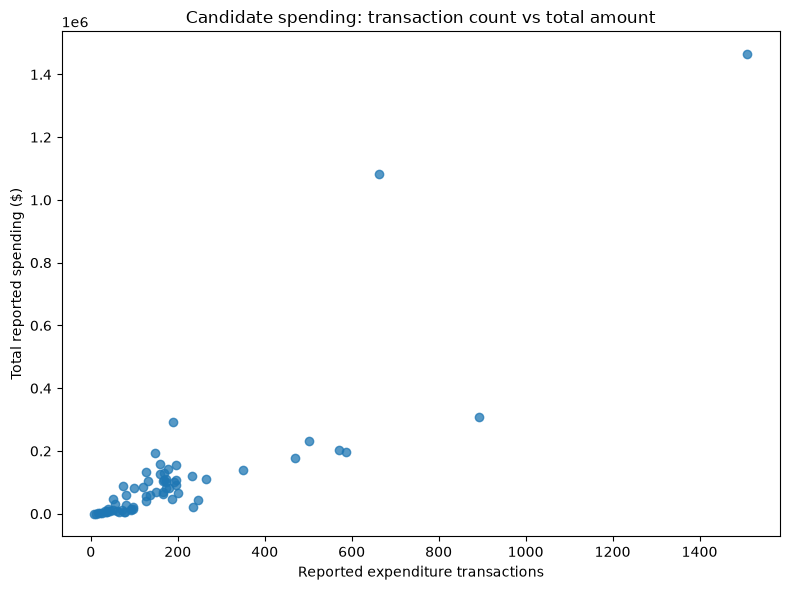

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    spending_summary["expenditure_count"],
    spending_summary["total_spending"],
    alpha=0.75,
)

ax.set_xlabel("Reported expenditure transactions")
ax.set_ylabel("Total reported spending ($)")
ax.set_title("Candidate spending: transaction count vs total amount")

plt.tight_layout()
plt.show()

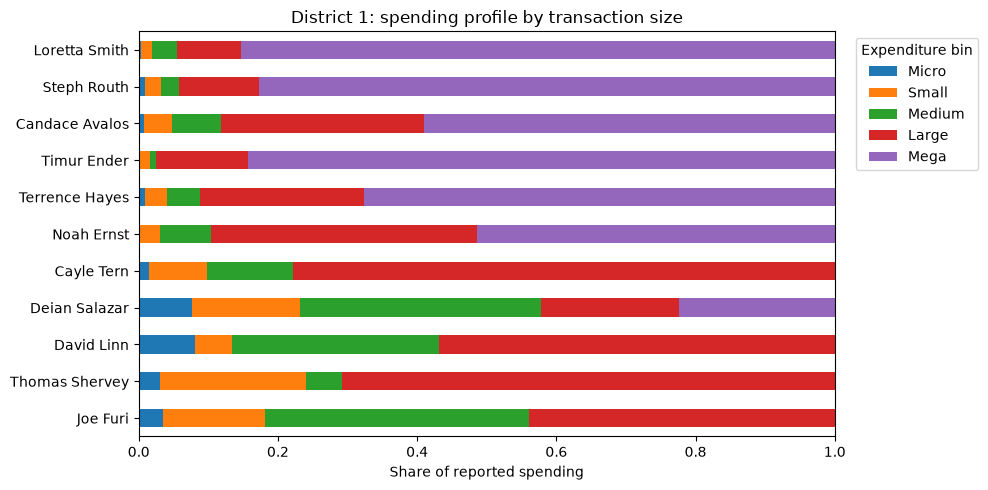

In [13]:
DISTRICT_TO_PLOT = 1

plot_table = (
    spending_profile_long.loc[
        spending_profile_long["district"].eq(DISTRICT_TO_PLOT)
    ]
    .pivot(
        index="canonical_candidate",
        columns="expenditure_bin",
        values="spending_amount_share",
    )
    .reindex(columns=BIN_LABELS)
    .fillna(0)
)

order = (
    spending_summary.loc[
        spending_summary["district"].eq(DISTRICT_TO_PLOT)
    ]
    .sort_values("total_spending", ascending=True)["canonical_candidate"]
)

plot_table = plot_table.reindex(order)

ax = plot_table.plot(
    kind="barh",
    stacked=True,
    figsize=(10, max(5, 0.35 * len(plot_table))),
)

ax.set_xlabel("Share of reported spending")
ax.set_ylabel("")
ax.set_title(
    f"District {DISTRICT_TO_PLOT}: spending profile by transaction size"
)

ax.legend(
    title="Expenditure bin",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

## 9. Export

In [14]:
summary_path = OUTPUT_DIR / "candidate_spending_summary.csv"
long_path = OUTPUT_DIR / "candidate_spending_profiles_long.csv"
wide_path = OUTPUT_DIR / "candidate_spending_profiles_wide.csv"

spending_summary.to_csv(summary_path, index=False)
spending_profile_long.to_csv(long_path, index=False)
spending_profile_wide.to_csv(wide_path, index=False)

print("SAVED", summary_path)
print("SAVED", long_path)
print("SAVED", wide_path)

SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/spending/2024/candidate_spending_summary.csv
SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/spending/2024/candidate_spending_profiles_long.csv
SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/spending/2024/candidate_spending_profiles_wide.csv
